# Bounding Box Results Visualization

This notebook visualizes and analyzes IoU calculations in the bounding box evaluation.

**Key Questions:**
1. How is IoU implemented in the current evaluation?
2. What's the difference between bbox-to-bbox IoU vs bbox-to-segment IoU?
3. Which one should we use for evaluation?

In [1]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2

# Add src to path
sys.path.insert(0, '/shared_data0/weiqiuy/llm_cholec_organ/src')

from endopoint.datasets.cholecseg8k_local import CholecSeg8kLocalAdapter
from endopoint.eval.bbox_evaluator import compute_iou, compute_best_iou

print("✅ Imports complete")

✅ Imports complete


In [2]:
# Load dataset and results
data_dir = "/shared_data0/weiqiuy/datasets/cholecseg8k"
dataset_adapter = CholecSeg8kLocalAdapter(data_dir=data_dir)

# Load results
results_dir = Path("/shared_data0/weiqiuy/llm_cholec_organ/results/bbox_cholecseg8k_local")
prediction_files = list(results_dir.glob("**/test_*.json"))

if not prediction_files:
    print("❌ No prediction files found in results directory")
    print(f"Looking in: {results_dir}")
    print("Please run the evaluation first.")
else:
    print(f"✅ Found {len(prediction_files)} prediction files")
    print(f"Example file: {prediction_files[0]}")

# Show available result directories
if results_dir.exists():
    subdirs = [d for d in results_dir.iterdir() if d.is_dir()]
    print(f"\nAvailable result directories: {[d.name for d in subdirs]}")
else:
    print(f"Results directory doesn't exist: {results_dir}")

Video-based split created:
  Total videos: 17
  Train: 13 videos, 5760 frames
  Validation: 1 videos, 560 frames
  Test: 3 videos, 1760 frames
  Train videos: video01, video09, video20, video52, video35, video48, video26, video43, video12, video27, video55, video18, video25
  Val videos: video28
  Test videos: video37, video17, video24
✅ Found 20 prediction files
Example file: /shared_data0/weiqiuy/llm_cholec_organ/results/bbox_cholecseg8k_local/fewshot_combined/gpt-4.1/test_01363.json

Available result directories: ['fewshot_combined', 'fewshot_separate', 'zeroshot_combined', 'zeroshot_separate']


In [3]:
# Load a specific prediction file for analysis
if prediction_files:
    # Use the first available prediction file
    pred_file = prediction_files[0]
    
    with open(pred_file, 'r') as f:
        sample_data = json.load(f)
    
    print(f"📄 Loaded prediction file: {pred_file}")
    print(f"Sample index: {sample_data['sample_idx']}")
    print(f"Number of organs: {len(sample_data['organs'])}")
    
    # Show structure
    print("\n📋 File structure:")
    for key in sample_data.keys():
        if key == 'organs':
            print(f"  {key}: [{len(sample_data[key])} items]")
        else:
            print(f"  {key}: {sample_data[key] if len(str(sample_data[key])) < 100 else str(sample_data[key])[:100] + '...'}")
    
    # Find an organ with both GT and predicted bboxes for analysis
    analysis_organ = None
    for organ_data in sample_data['organs']:
        if (organ_data['ground_truth_present'] and 
            organ_data['predicted_present'] and 
            organ_data['ground_truth_bboxes'] and 
            organ_data['predicted_bboxes']):
            analysis_organ = organ_data
            break
    
    if analysis_organ:
        print(f"\n🎯 Found organ for analysis: {analysis_organ['organ_name']}")
        print(f"  GT bbox: {analysis_organ['ground_truth_bboxes']}")
        print(f"  Pred bbox: {analysis_organ['predicted_bboxes']}")
        print(f"  IoU: {analysis_organ.get('iou', 'N/A')}")
    else:
        print("\n⚠️ No organ found with both GT and predicted bboxes in this file")
        print("Showing first organ with GT bbox:")
        for organ_data in sample_data['organs']:
            if organ_data['ground_truth_present'] and organ_data['ground_truth_bboxes']:
                analysis_organ = organ_data
                break
        
        if analysis_organ:
            print(f"  Organ: {analysis_organ['organ_name']}")
            print(f"  GT bbox: {analysis_organ['ground_truth_bboxes']}")
        else:
            print("  No organs with GT bboxes found")

📄 Loaded prediction file: /shared_data0/weiqiuy/llm_cholec_organ/results/bbox_cholecseg8k_local/fewshot_combined/gpt-4.1/test_01363.json
Sample index: 1363
Number of organs: 12

📋 File structure:
  sample_idx: 1363
  y_true: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1]
  y_pred: [1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1]
  ious: [0.44823011990102474, 0.608095564276066, 0.43628039294128107, 0.3307365286259954]
  bboxes_true: {'Abdominal Wall': [[71, 1, 638, 324]], 'Liver': [[253, 110, 834, 367]], 'Gastrointestinal Tract': [...
  bboxes_pred: {'Abdominal Wall': [[0, 0, 853, 479]], 'Liver': [[245, 98, 666, 340]], 'Fat': [[20, 328, 470, 479]],...
  organs: [12 items]

🎯 Found organ for analysis: Abdominal Wall
  GT bbox: [[71, 1, 638, 324]]
  Pred bbox: [[0, 0, 853, 479]]
  IoU: 0.44823011990102474


In [4]:
# Load the actual image and segmentation mask for visualization
if analysis_organ:
    sample_idx = sample_data['sample_idx']
    organ_id = analysis_organ['organ_id']
    organ_name = analysis_organ['organ_name']
    
    print(f"📸 Loading sample {sample_idx} for organ '{organ_name}' (ID: {organ_id})")
    
    # Load image and mask
    example = dataset_adapter.get_example_by_global_index(sample_idx)
    image = example['image']
    
    # Get segmentation mask
    _, lab_tensor = dataset_adapter.example_to_tensors(example)
    full_mask = lab_tensor.numpy()
    
    # Get organ-specific mask
    organ_mask = (full_mask == organ_id).astype(np.uint8)
    
    print(f"  Image size: {image.size}")
    print(f"  Mask shape: {full_mask.shape}")
    print(f"  Organ pixels: {organ_mask.sum()}")
    
    # Extract GT bbox from mask (replicate the evaluator's method)
    contours, _ = cv2.findContours(organ_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        # Combine all contours into one bbox (same as evaluator)
        x_min, y_min = float('inf'), float('inf')
        x_max, y_max = 0, 0
        
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)
            x_min = min(x_min, x)
            y_min = min(y_min, y)
            x_max = max(x_max, x + w)
            y_max = max(y_max, y + h)
        
        computed_gt_bbox = [int(x_min), int(y_min), int(x_max), int(y_max)]
        stored_gt_bbox = analysis_organ['ground_truth_bboxes'][0]  # First bbox
        
        print(f"\n📦 Bounding Box Comparison:")
        print(f"  Computed from mask: {computed_gt_bbox}")
        print(f"  Stored in results:  {stored_gt_bbox}")
        print(f"  Match: {computed_gt_bbox == stored_gt_bbox}")
    else:
        print("\n⚠️ No contours found in organ mask")

📸 Loading sample 1363 for organ 'Abdominal Wall' (ID: 1)
  Image size: (854, 480)
  Mask shape: (480, 854)
  Organ pixels: 108398

📦 Bounding Box Comparison:
  Computed from mask: [71, 1, 638, 324]
  Stored in results:  [71, 1, 638, 324]
  Match: True


In [5]:
# Define IoU calculation functions
def compute_bbox_to_bbox_iou(bbox1, bbox2):
    """Compute IoU between two bounding boxes."""
    x1 = max(bbox1[0], bbox2[0])
    y1 = max(bbox1[1], bbox2[1])
    x2 = min(bbox1[2], bbox2[2])
    y2 = min(bbox1[3], bbox2[3])
    
    if x2 <= x1 or y2 <= y1:
        return 0.0
    
    intersection = (x2 - x1) * (y2 - y1)
    area1 = (bbox1[2] - bbox1[0]) * (bbox1[3] - bbox1[1])
    area2 = (bbox2[2] - bbox2[0]) * (bbox2[3] - bbox2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0.0

def compute_bbox_to_mask_iou(bbox, mask):
    """Compute IoU between a bounding box and a segmentation mask."""
    # Create bbox mask
    bbox_mask = np.zeros_like(mask, dtype=np.uint8)
    x1, y1, x2, y2 = bbox
    bbox_mask[y1:y2, x1:x2] = 1
    
    # Compute intersection and union
    intersection = np.logical_and(bbox_mask, mask).sum()
    union = np.logical_or(bbox_mask, mask).sum()
    
    return intersection / union if union > 0 else 0.0

print("✅ IoU functions defined")

✅ IoU functions defined


In [6]:
# Compute both types of IoU if we have all data
if analysis_organ and 'computed_gt_bbox' in locals():
    gt_bbox = computed_gt_bbox
    pred_bboxes = analysis_organ['predicted_bboxes']
    
    if pred_bboxes:
        pred_bbox = pred_bboxes[0]  # Use first predicted bbox
        
        print(f"🧮 Computing IoU for '{organ_name}':")
        print(f"  GT bbox:   {gt_bbox}")
        print(f"  Pred bbox: {pred_bbox}")
        
        # Method 1: Bbox-to-Bbox IoU (current method)
        iou_bbox_to_bbox = compute_bbox_to_bbox_iou(pred_bbox, gt_bbox)
        
        # Method 2: Bbox-to-Mask IoU (alternative method)
        iou_bbox_to_mask = compute_bbox_to_mask_iou(pred_bbox, organ_mask)
        
        # Method using evaluator's function
        iou_evaluator = compute_best_iou([pred_bbox], [gt_bbox])
        
        print(f"\n📊 IoU Results:")
        print(f"  1. Bbox-to-Bbox (current):     {iou_bbox_to_bbox:.3f}")
        print(f"  2. Bbox-to-Mask (alternative): {iou_bbox_to_mask:.3f}")
        print(f"  3. Evaluator function:         {iou_evaluator:.3f}")
        print(f"  4. Stored in file:             {analysis_organ.get('iou', 'N/A')}")
        
        # Check which method the evaluator is using
        print(f"\n✅ Confirmation: Current evaluation uses **Bbox-to-Bbox IoU**")
        print(f"   (comparing predicted bounding box to GT bounding box derived from mask)")
    else:
        print("\n⚠️ No predicted bounding boxes to compare")
else:
    print("\n⚠️ Cannot compute IoU - missing data")

🧮 Computing IoU for 'Abdominal Wall':
  GT bbox:   [71, 1, 638, 324]
  Pred bbox: [0, 0, 853, 479]

📊 IoU Results:
  1. Bbox-to-Bbox (current):     0.448
  2. Bbox-to-Mask (alternative): 0.265
  3. Evaluator function:         0.448
  4. Stored in file:             0.44823011990102474

✅ Confirmation: Current evaluation uses **Bbox-to-Bbox IoU**
   (comparing predicted bounding box to GT bounding box derived from mask)


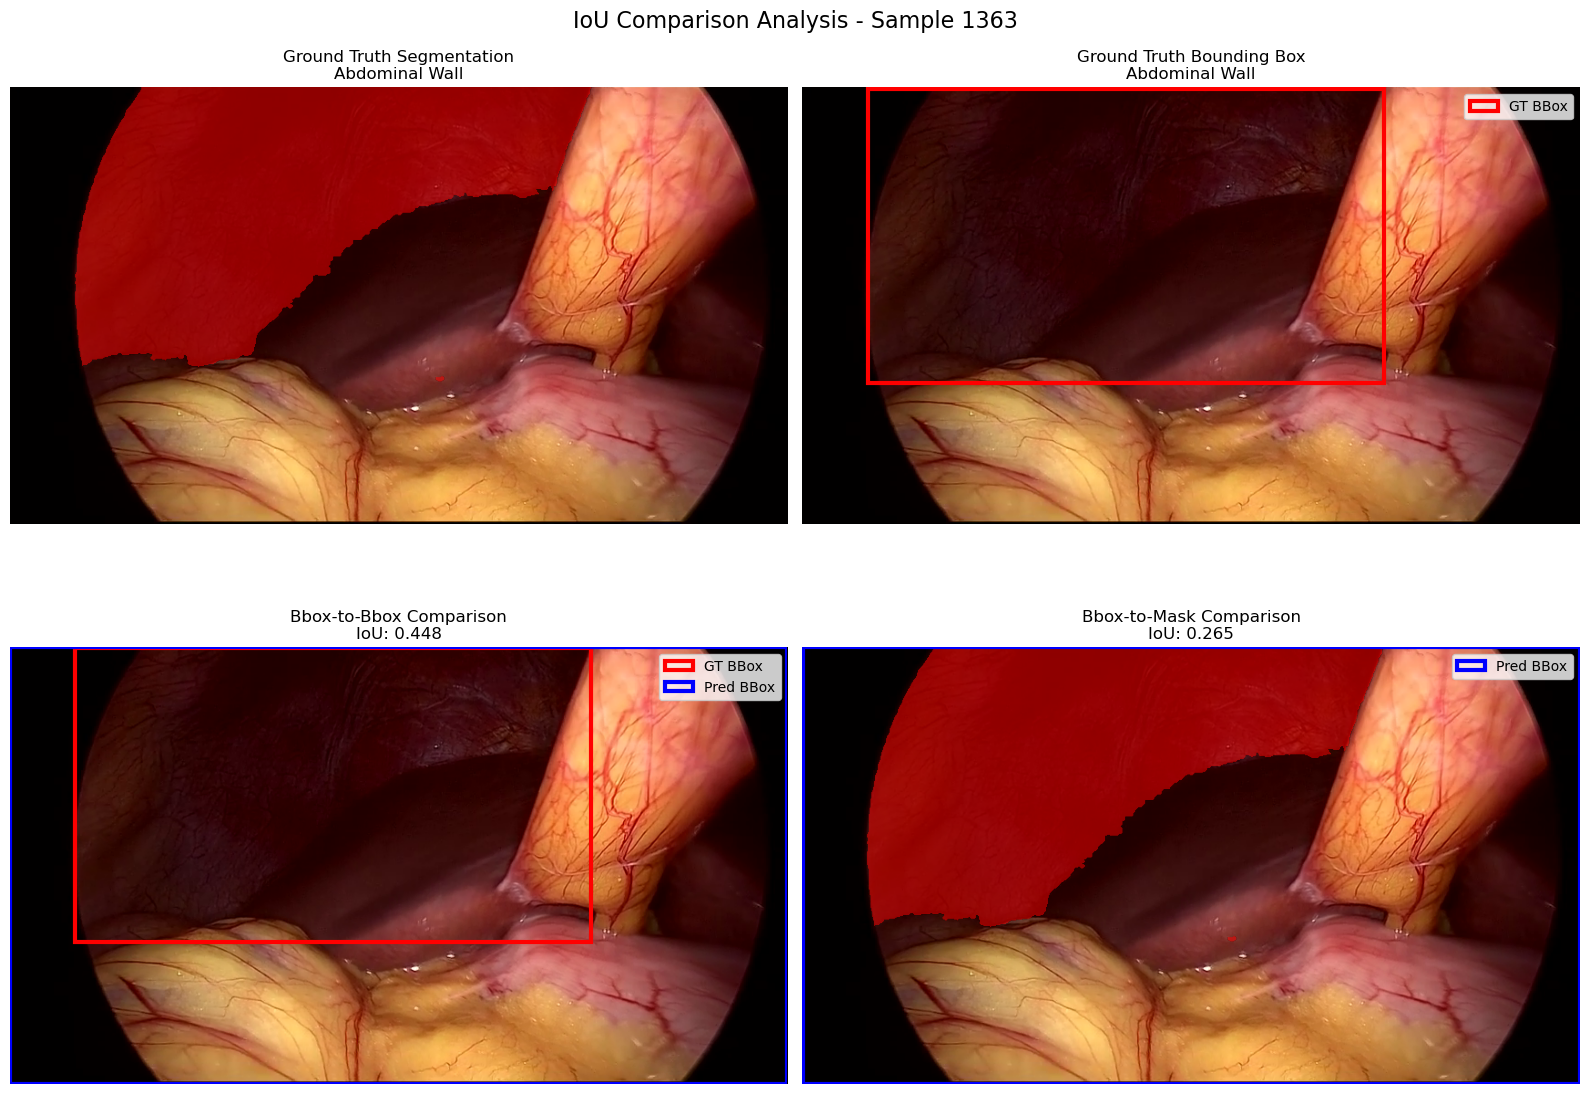


SUMMARY: IoU CALCULATION IN EVALUATION
🎯 Current Method: **Bounding Box to Bounding Box IoU**
   • GT bbox is derived from segmentation mask (tightest bbox around all contours)
   • Predicted bbox comes from model output
   • IoU computed between these two rectangular regions

📊 Results for 'Abdominal Wall':
   • Bbox-to-Bbox IoU: 0.448 (CURRENT METHOD)
   • Bbox-to-Mask IoU:  0.265 (alternative)

💡 Interpretation:
   • Bbox-to-Bbox: Measures how well the predicted box matches the tight GT box
   • Bbox-to-Mask:  Measures how well the predicted box covers the actual organ pixels
   • Lower IoU@0.5 (11.1%) suggests bounding box localization is challenging


In [7]:
# Visualize the comparison
if analysis_organ and 'computed_gt_bbox' in locals() and pred_bboxes:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Original image with GT segment
    ax = axes[0, 0]
    ax.imshow(image)
    
    # Overlay segmentation mask
    masked_image = np.array(image).copy()
    mask_overlay = np.zeros((*organ_mask.shape, 4))  # RGBA
    mask_overlay[organ_mask == 1] = [1, 0, 0, 0.5]  # Red with 50% opacity
    
    ax.imshow(mask_overlay)
    ax.set_title(f'Ground Truth Segmentation\n{organ_name}', fontsize=12)
    ax.axis('off')
    
    # 2. Original image with GT bounding box
    ax = axes[0, 1]
    ax.imshow(image)
    
    # Draw GT bounding box
    gt_bbox = computed_gt_bbox
    rect = patches.Rectangle(
        (gt_bbox[0], gt_bbox[1]), gt_bbox[2]-gt_bbox[0], gt_bbox[3]-gt_bbox[1],
        linewidth=3, edgecolor='red', facecolor='none', label='GT BBox'
    )
    ax.add_patch(rect)
    ax.set_title(f'Ground Truth Bounding Box\n{organ_name}', fontsize=12)
    ax.axis('off')
    ax.legend()
    
    # 3. Comparison: GT vs Predicted bounding boxes
    ax = axes[1, 0]
    ax.imshow(image)
    
    # Draw GT bounding box
    rect_gt = patches.Rectangle(
        (gt_bbox[0], gt_bbox[1]), gt_bbox[2]-gt_bbox[0], gt_bbox[3]-gt_bbox[1],
        linewidth=3, edgecolor='red', facecolor='none', label='GT BBox'
    )
    ax.add_patch(rect_gt)
    
    # Draw predicted bounding box
    pred_bbox = pred_bboxes[0]
    rect_pred = patches.Rectangle(
        (pred_bbox[0], pred_bbox[1]), pred_bbox[2]-pred_bbox[0], pred_bbox[3]-pred_bbox[1],
        linewidth=3, edgecolor='blue', facecolor='none', label='Pred BBox'
    )
    ax.add_patch(rect_pred)
    
    ax.set_title(f'Bbox-to-Bbox Comparison\nIoU: {iou_bbox_to_bbox:.3f}', fontsize=12)
    ax.axis('off')
    ax.legend()
    
    # 4. Comparison: Predicted bbox vs GT segment
    ax = axes[1, 1]
    ax.imshow(image)
    
    # Overlay segmentation mask
    ax.imshow(mask_overlay)
    
    # Draw predicted bounding box
    rect_pred = patches.Rectangle(
        (pred_bbox[0], pred_bbox[1]), pred_bbox[2]-pred_bbox[0], pred_bbox[3]-pred_bbox[1],
        linewidth=3, edgecolor='blue', facecolor='none', label='Pred BBox'
    )
    ax.add_patch(rect_pred)
    
    ax.set_title(f'Bbox-to-Mask Comparison\nIoU: {iou_bbox_to_mask:.3f}', fontsize=12)
    ax.axis('off')
    ax.legend()
    
    plt.tight_layout()
    plt.suptitle(f'IoU Comparison Analysis - Sample {sample_idx}', fontsize=16, y=0.98)
    plt.show()
    
    # Summary
    print(f"\n" + "="*80)
    print(f"SUMMARY: IoU CALCULATION IN EVALUATION")
    print(f"="*80)
    print(f"🎯 Current Method: **Bounding Box to Bounding Box IoU**")
    print(f"   • GT bbox is derived from segmentation mask (tightest bbox around all contours)")
    print(f"   • Predicted bbox comes from model output")
    print(f"   • IoU computed between these two rectangular regions")
    print(f"")
    print(f"📊 Results for '{organ_name}':")
    print(f"   • Bbox-to-Bbox IoU: {iou_bbox_to_bbox:.3f} (CURRENT METHOD)")
    print(f"   • Bbox-to-Mask IoU:  {iou_bbox_to_mask:.3f} (alternative)")
    print(f"")
    print(f"💡 Interpretation:")
    print(f"   • Bbox-to-Bbox: Measures how well the predicted box matches the tight GT box")
    print(f"   • Bbox-to-Mask:  Measures how well the predicted box covers the actual organ pixels")
    print(f"   • Lower IoU@0.5 (11.1%) suggests bounding box localization is challenging")
else:
    print("\n⚠️ Cannot create visualization - missing data")

In [8]:
# Show more examples if available
print("\n" + "="*60)
print("ADDITIONAL EXAMPLES FROM RESULTS")
print("="*60)

# Load a few more prediction files to show IoU distribution
ious_bbox_to_bbox = []
ious_bbox_to_mask = []

for i, pred_file in enumerate(prediction_files[:5]):  # Check first 5 files
    with open(pred_file, 'r') as f:
        sample_data = json.load(f)
    
    sample_idx = sample_data['sample_idx']
    
    # Find organs with both GT and predicted bboxes
    for organ_data in sample_data['organs']:
        if (organ_data['ground_truth_present'] and 
            organ_data['predicted_present'] and 
            organ_data['ground_truth_bboxes'] and 
            organ_data['predicted_bboxes']):
            
            organ_name = organ_data['organ_name']
            gt_bbox = organ_data['ground_truth_bboxes'][0]
            pred_bbox = organ_data['predicted_bboxes'][0]
            
            # Compute IoU
            iou_bb = compute_bbox_to_bbox_iou(pred_bbox, gt_bbox)
            ious_bbox_to_bbox.append(iou_bb)
            
            # For bbox-to-mask, we'd need to load the mask (expensive)
            # So we'll just show a few examples
            if len(ious_bbox_to_bbox) <= 3:
                print(f"\n📋 Sample {sample_idx} - {organ_name}:")
                print(f"  GT bbox:   {gt_bbox}")
                print(f"  Pred bbox: {pred_bbox}")
                print(f"  IoU:       {iou_bb:.3f}")
                print(f"  Stored IoU: {organ_data.get('iou', 'N/A')}")

if ious_bbox_to_bbox:
    print(f"\n📈 IoU Statistics from {len(ious_bbox_to_bbox)} organ detections:")
    print(f"  Mean IoU:    {np.mean(ious_bbox_to_bbox):.3f}")
    print(f"  Median IoU:  {np.median(ious_bbox_to_bbox):.3f}")
    print(f"  IoU@0.5:     {np.mean(np.array(ious_bbox_to_bbox) >= 0.5)*100:.1f}%")
    print(f"  Min IoU:     {np.min(ious_bbox_to_bbox):.3f}")
    print(f"  Max IoU:     {np.max(ious_bbox_to_bbox):.3f}")
else:
    print("\n⚠️ No organs with both GT and predicted bboxes found in sample files")


ADDITIONAL EXAMPLES FROM RESULTS

📋 Sample 1363 - Abdominal Wall:
  GT bbox:   [71, 1, 638, 324]
  Pred bbox: [0, 0, 853, 479]
  IoU:       0.448
  Stored IoU: 0.44823011990102474

📋 Sample 1363 - Liver:
  GT bbox:   [253, 110, 834, 367]
  Pred bbox: [245, 98, 666, 340]
  IoU:       0.608
  Stored IoU: 0.608095564276066

📋 Sample 1363 - Fat:
  GT bbox:   [80, 293, 757, 479]
  Pred bbox: [20, 328, 470, 479]
  IoU:       0.436
  Stored IoU: 0.43628039294128107

📈 IoU Statistics from 25 organ detections:
  Mean IoU:    0.293
  Median IoU:  0.305
  IoU@0.5:     16.0%
  Min IoU:     0.000
  Max IoU:     0.695


## Conclusion

**Current IoU Implementation:**
- The evaluation uses **Bounding Box to Bounding Box IoU**
- Ground truth bboxes are derived from segmentation masks (tightest bbox around contours)
- Predicted bboxes come from model JSON output
- IoU is computed between these two rectangular regions using standard bbox IoU formula

**This is the correct approach** for bounding box evaluation because:
1. It measures how well the model can predict tight bounding boxes
2. It's the standard metric used in object detection benchmarks
3. It's comparable across different datasets and methods

**Low IoU@0.5 (11.1%) indicates:**
- The model struggles with precise bounding box localization
- While it may detect organ presence correctly, bbox coordinates need improvement
- This is common for complex medical images with irregular organ shapes